# Iris Flower Classification

**Oasis Infobyte — Data Science Internship**  
**Task 1 — Iris Flower Classification**  
**Author:** Md. Zayed Hossain

This notebook builds and evaluates machine-learning classifiers that identify Iris flowers as **Setosa, Versicolor, or Virginica** from four physical measurements.

## 1. Project Title

**Iris Flower Classification — Oasis Infobyte Data Science Internship, Task 1**

## 2. Internship Information

- **Organization:** Oasis Infobyte
- **Track:** Data Science
- **Task:** Task 1 — Iris Flower Classification
- **Author:** Md. Zayed Hossain
- **GitHub Repository:** `OIBSIP`
- **Project Folder:** `DataScience-Task1-IrisFlowerClassification`

## 3. Objective

Train classification models that predict the species of an Iris flower from sepal length, sepal width, petal length, and petal width. The project compares multiple classifiers and selects the best model using reproducible evaluation results.

## 4. Problem Statement

The Iris dataset contains measurements for three flower species. The goal is to learn the relationship between those measurements and species labels, then evaluate how accurately unseen flowers can be classified.

## 5. Import Libraries

Only libraries needed for data handling, visualization, preprocessing, modeling, and evaluation are imported.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.datasets import load_iris
from sklearn.feature_selection import f_classif
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

RANDOM_STATE = 42
TEST_SIZE = 0.20

PROJECT_ROOT = Path.cwd()
IMAGES_DIR = PROJECT_ROOT / "images"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
IMAGES_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)

## 6. Load Iris Dataset

The official task specifies using the Iris dataset included with scikit-learn, so no external dataset download is required.

In [2]:
iris = load_iris(as_frame=True)

# Feature matrix and target supplied by scikit-learn
X_full = iris.data.copy()
y_full = iris.target.copy()

# Build a readable DataFrame for EDA
df = X_full.copy()
df["species"] = y_full.map(dict(enumerate(iris.target_names)))

display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 7. Dataset Overview

Inspect the dataset shape, column names, data types, metadata, and descriptive statistics before modeling.

In [3]:
print(f"Dataset shape: {df.shape}")
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nDataFrame info:")
df.info()

print("\nDescriptive statistics:")
display(df.describe(include="all"))

Dataset shape: (150, 5)

Column names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']

Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Descriptive statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


## 8. Data Quality Assessment

Check for missing values and exact duplicate observations. A duplicate is not automatically an error; in a measured dataset, two real samples can share identical values.

In [4]:
missing_values = df.isna().sum()
duplicate_count = int(df.duplicated().sum())

audit = pd.DataFrame({
    "Missing Values": missing_values,
    "Data Type": df.dtypes.astype(str),
})

display(audit)
print(f"Exact duplicate rows: {duplicate_count}")

if duplicate_count:
    print("\nDuplicate observation(s):")
    display(df[df.duplicated(keep=False)])

,Missing Values,Data Type
sepal length (cm),0,float64
sepal width (cm),0,float64
petal length (cm),0,float64
petal width (cm),0,float64
species,0,object


Exact duplicate rows: 1

Duplicate observation(s):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


## 9. Data Cleaning

The dataset is checked for missing values and duplicates. Missing values would require treatment before modeling. Exact duplicate measurements are reviewed rather than deleted automatically so the canonical scikit-learn dataset remains intact unless there is evidence that a row is erroneous.

In [5]:
if df.isna().sum().sum() == 0:
    print("No missing values were found; no imputation is required.")
else:
    print("Missing values are present and require treatment.")

if duplicate_count > 0:
    print(
        f"{duplicate_count} exact duplicate row was found. It is retained because the task uses "
        "the canonical scikit-learn Iris dataset and identical measurements can represent valid samples."
    )
else:
    print("No exact duplicate rows were found.")

No missing values were found; no imputation is required.
1 exact duplicate row was found. It is retained because the task uses the canonical scikit-learn Iris dataset and identical measurements can represent valid samples.


## 10. Exploratory Data Analysis

EDA is used to understand class balance, feature distributions, relationships between measurements, and how clearly the species separate before training models.

## 11. Species Distribution

A balanced target distribution helps make accuracy and macro-averaged classification metrics easier to interpret across all three species.

Species counts:


,count
species,
setosa,50
versicolor,50
virginica,50


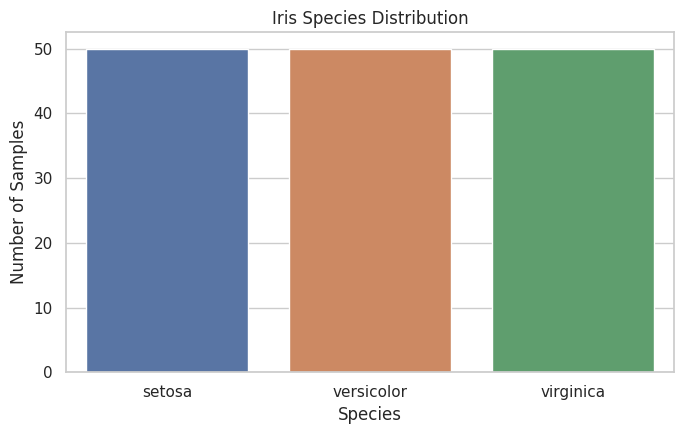

In [6]:
species_counts = df["species"].value_counts().reindex(iris.target_names)
print("Species counts:")
display(species_counts.rename("count").to_frame())

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.countplot(data=df, x="species", hue="species", order=iris.target_names, hue_order=iris.target_names, legend=False, ax=ax)
ax.set_title("Iris Species Distribution")
ax.set_xlabel("Species")
ax.set_ylabel("Number of Samples")
fig.tight_layout()
fig.savefig(IMAGES_DIR / "species_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

**Interpretation:** The classes are evenly represented, so no species dominates the dataset. This reduces the risk that a high overall accuracy is caused simply by predicting a majority class.

## 12. Pairplot / Feature Relationships

The pairplot shows pairwise relationships among the four measurements and uses species labels to reveal how strongly each feature combination separates the classes.

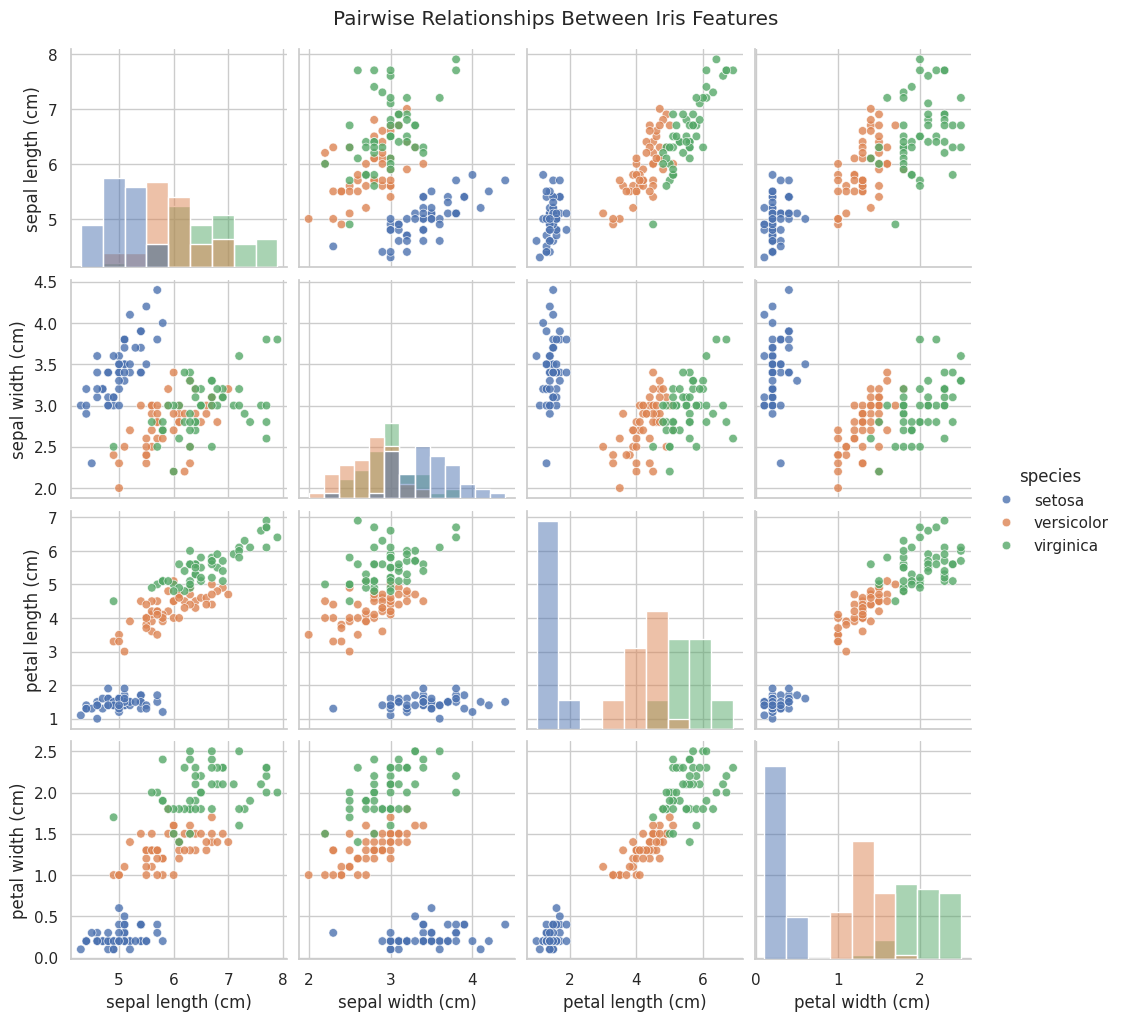

In [7]:
pairplot = sns.pairplot(
    df,
    vars=iris.feature_names,
    hue="species",
    diag_kind="hist",
    corner=False,
    plot_kws={"alpha": 0.8, "s": 38},
)
pairplot.fig.suptitle("Pairwise Relationships Between Iris Features", y=1.02)
pairplot.savefig(IMAGES_DIR / "iris_pairplot.png", dpi=180, bbox_inches="tight")
plt.show()

**Interpretation:** Petal length and petal width show visibly stronger species separation than the sepal measurements. Setosa forms a particularly distinct cluster, while Versicolor and Virginica overlap more but are still separated well by petal dimensions.

## 13. Box Plot Analysis

Box plots compare feature distributions across species and make overlap, spread, and median differences easy to see.

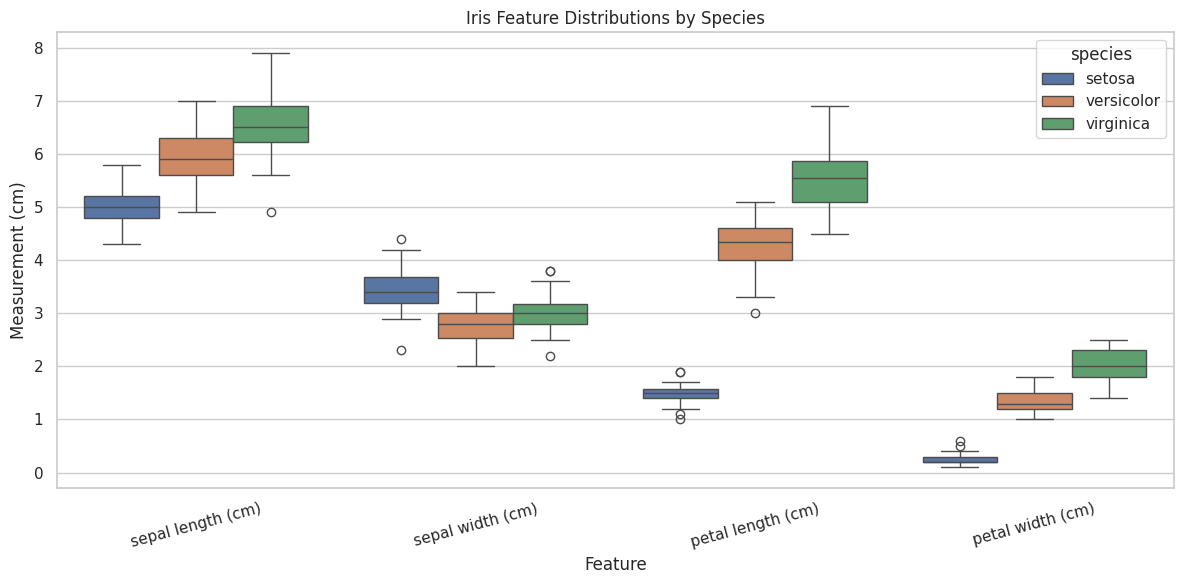

In [8]:
long_df = df.melt(
    id_vars="species",
    value_vars=iris.feature_names,
    var_name="feature",
    value_name="measurement_cm",
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=long_df, x="feature", y="measurement_cm", hue="species", ax=ax)
ax.set_title("Iris Feature Distributions by Species")
ax.set_xlabel("Feature")
ax.set_ylabel("Measurement (cm)")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(IMAGES_DIR / "feature_boxplots.png", dpi=180, bbox_inches="tight")
plt.show()

**Interpretation:** The petal measurements have much clearer between-species differences. Sepal width has substantial overlap, making it less useful on its own for distinguishing all three species.

### Additional Correlation View

A correlation heatmap is included as a useful supporting EDA view. It is not a replacement for the required pairplot and box plots.

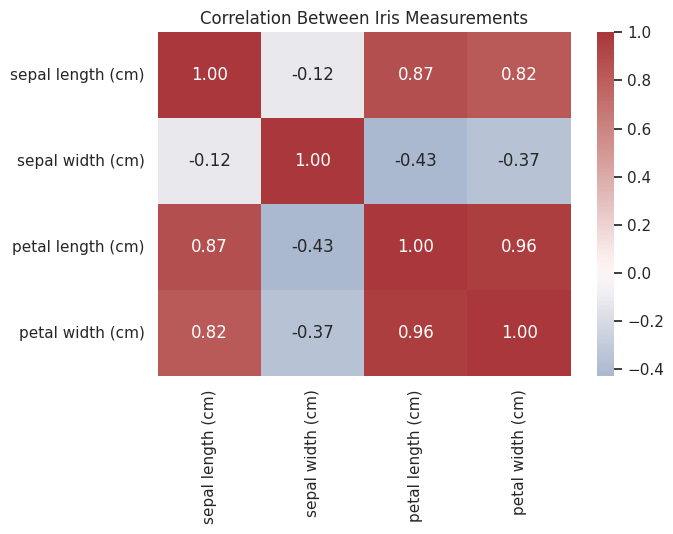

In [9]:
fig, ax = plt.subplots(figsize=(7, 5.5))
corr = df[iris.feature_names].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Correlation Between Iris Measurements")
fig.tight_layout()
fig.savefig(IMAGES_DIR / "feature_correlation_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

## 14. Key EDA Observations

- All three species have equal sample counts.
- Petal length and petal width provide the clearest visual separation between species.
- Setosa is especially easy to distinguish using petal measurements.
- Versicolor and Virginica overlap more than Setosa, so their boundary is the main classification challenge.
- Sepal width overlaps considerably across species and is less discriminative by itself.

## 15. Feature Discriminative Analysis

To support the visual analysis with a numerical measure, a one-way ANOVA F-test is calculated for each feature. A larger F-score indicates stronger differences between species group means relative to within-species variation.

,Feature,ANOVA F-score,p-value
2,petal length (cm),1180.161182,2.856777e-91
3,petal width (cm),960.007147,4.169446e-85
0,sepal length (cm),119.264502,1.669669e-31
1,sepal width (cm),49.160040,4.492017e-17


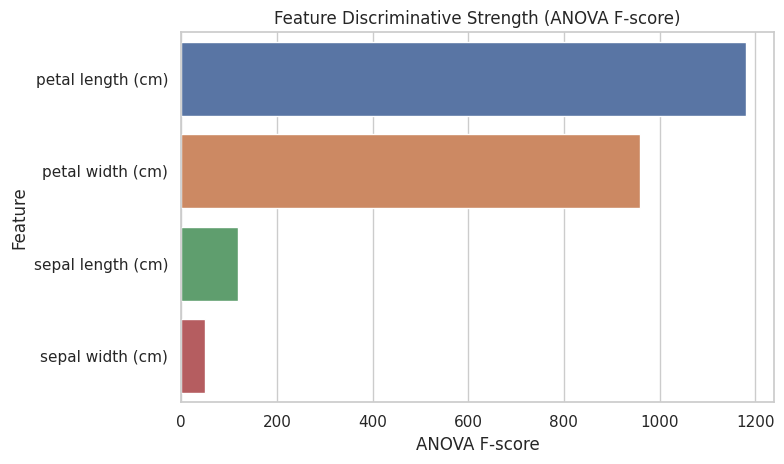

**Most discriminative features:** petal length (cm), petal width (cm). They have the highest ANOVA F-scores and also show the clearest separation in the pairplot and box plots.

In [10]:
f_scores, p_values = f_classif(X_full, y_full)
feature_scores = pd.DataFrame({
    "Feature": iris.feature_names,
    "ANOVA F-score": f_scores,
    "p-value": p_values,
}).sort_values("ANOVA F-score", ascending=False)

display(feature_scores)
feature_scores.to_csv(OUTPUTS_DIR / "feature_discriminative_scores.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4.8))
sns.barplot(data=feature_scores, x="ANOVA F-score", y="Feature", hue="Feature", legend=False, ax=ax)
ax.set_title("Feature Discriminative Strength (ANOVA F-score)")
ax.set_xlabel("ANOVA F-score")
ax.set_ylabel("Feature")
fig.tight_layout()
fig.savefig(IMAGES_DIR / "feature_discriminative_scores.png", dpi=180, bbox_inches="tight")
plt.show()

best_features = feature_scores.head(2)["Feature"].tolist()
display(Markdown(
    "**Most discriminative features:** " + ", ".join(best_features) + 
    ". They have the highest ANOVA F-scores and also show the clearest separation in the pairplot and box plots."
))

### Which features are most discriminative, and why?

The strongest features are expected to be the **petal measurements**. The final determination above is based on two pieces of evidence generated from the actual dataset: (1) visual separation in the pairplot/box plots and (2) the ANOVA F-scores. These features vary much more between species than within species, so they carry stronger class-separation information than the sepal measurements.

## 16. Feature / Target Separation

The four measurements are used as input features, while the numeric species label supplied by scikit-learn is the target.

In [11]:
X = X_full.copy()
y = y_full.copy()

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Target classes:", dict(enumerate(iris.target_names)))

Feature matrix shape: (150, 4)
Target vector shape: (150,)
Target classes: {0: np.str_('setosa'), 1: np.str_('versicolor'), 2: np.str_('virginica')}


## 17. Train/Test Split

Use an **80/20 stratified split** with `random_state=42`. Stratification preserves the equal class proportions in both training and test sets.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("\nTraining class counts:")
print(y_train.value_counts().sort_index())
print("\nTesting class counts:")
print(y_test.value_counts().sort_index())

Training samples: 120
Testing samples: 30

Training class counts:
target
0    40
1    40
2    40
Name: count, dtype: int64

Testing class counts:
target
0    10
1    10
2    10
Name: count, dtype: int64


## 18. Preprocessing

Logistic Regression and K-Nearest Neighbors are sensitive to feature scale, so `StandardScaler` is placed inside a scikit-learn `Pipeline`. This ensures the scaler is fitted only on training data and prevents data leakage. Tree-based models do not require scaling.

In [13]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5)),
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
    ),
}

print("Configured models:")
for model_name in models:
    print("-", model_name)

Configured models:
- Logistic Regression
- K-Nearest Neighbors
- Decision Tree
- Random Forest


## 19. Model Training

Four classifiers are trained to provide a stronger comparison while remaining easy to explain: Logistic Regression, KNN, Decision Tree, and Random Forest.

In [14]:
for model in models.values():
    model.fit(X_train, y_train)

print(f"Successfully trained {len(models)} classification models.")

Successfully trained 4 classification models.


## 20. Model Evaluation

Each model is evaluated on the same held-out test set using accuracy, macro precision, macro recall, macro F1-score, confusion matrix, and a full classification report. Five-fold stratified cross-validation on the training set is included only as a stability/tie-breaker check.

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []
predictions = {}
confusion_matrices = {}
classification_reports = {}

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    predictions[model_name] = y_pred
    confusion_matrices[model_name] = confusion_matrix(y_test, y_pred)
    classification_reports[model_name] = classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names,
        digits=4,
    )

    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_macro")

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall (Macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1-score (Macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "CV F1 Mean": cv_scores.mean(),
        "CV F1 Std": cv_scores.std(),
    })

model_comparison = pd.DataFrame(results).sort_values(
    ["F1-score (Macro)", "Accuracy", "CV F1 Mean"],
    ascending=False,
).reset_index(drop=True)

model_comparison.to_csv(OUTPUTS_DIR / "model_comparison.csv", index=False)
display(model_comparison.style.format({
    "Accuracy": "{:.4f}",
    "Precision (Macro)": "{:.4f}",
    "Recall (Macro)": "{:.4f}",
    "F1-score (Macro)": "{:.4f}",
    "CV F1 Mean": "{:.4f}",
    "CV F1 Std": "{:.4f}",
}))

for model_name in models:
    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print(classification_reports[model_name])

with open(OUTPUTS_DIR / "classification_reports.txt", "w", encoding="utf-8") as report_file:
    for model_name in models:
        report_file.write("=" * 80 + "\n")
        report_file.write(model_name + "\n")
        report_file.write("=" * 80 + "\n")
        report_file.write(classification_reports[model_name] + "\n")

,Model,Accuracy,Precision (Macro),Recall (Macro),F1-score (Macro),CV F1 Mean,CV F1 Std
0,Logistic Regression,0.9333,0.9333,0.9333,0.9333,0.9580,0.0268
1,Decision Tree,0.9333,0.9333,0.9333,0.9333,0.9496,0.0171
2,K-Nearest Neighbors,0.9333,0.9444,0.9333,0.9327,0.9580,0.0268
3,Random Forest,0.9000,0.9024,0.9000,0.8997,0.9494,0.0317


Logistic Regression
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.9000    0.9000    0.9000        10
   virginica     0.9000    0.9000    0.9000        10

    accuracy                         0.9333        30
   macro avg     0.9333    0.9333    0.9333        30
weighted avg     0.9333    0.9333    0.9333        30

K-Nearest Neighbors
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.8333    1.0000    0.9091        10
   virginica     1.0000    0.8000    0.8889        10

    accuracy                         0.9333        30
   macro avg     0.9444    0.9333    0.9327        30
weighted avg     0.9444    0.9333    0.9327        30

Decision Tree
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.9000    0.9000    0.9000        10
   virginica     0.90

## 21. Confusion Matrices

A confusion matrix is saved for every model so correct and incorrect predictions can be inspected by class rather than relying only on aggregate metrics.

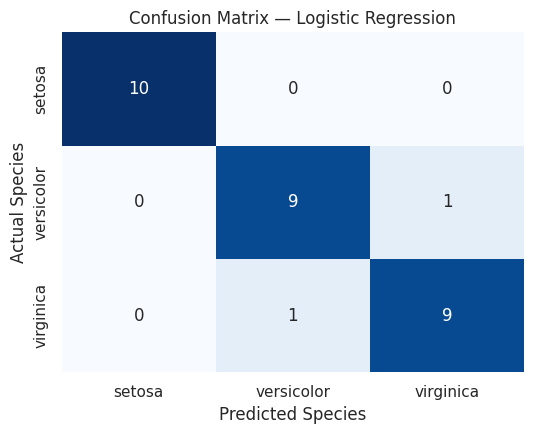

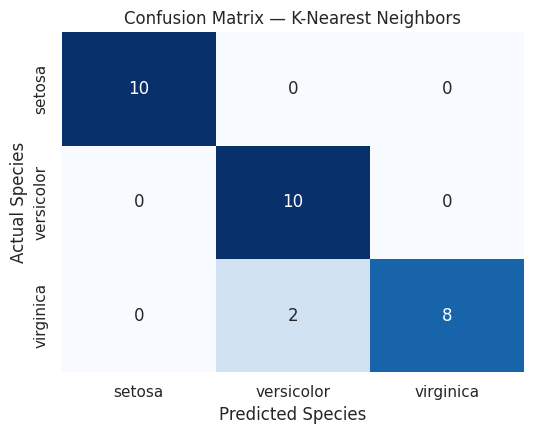

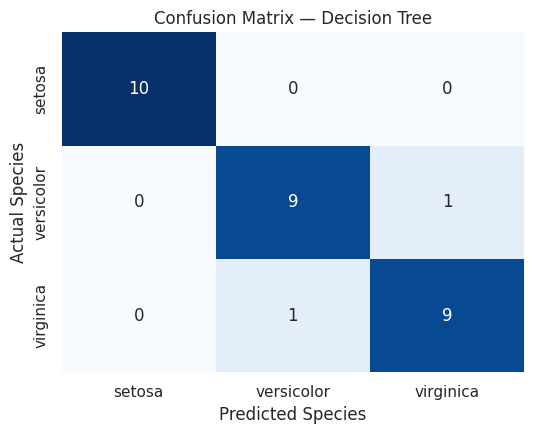

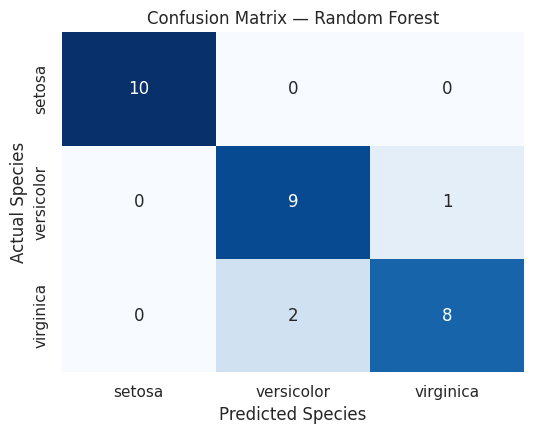

In [16]:
for model_name, matrix in confusion_matrices.items():
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=iris.target_names,
        yticklabels=iris.target_names,
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix — {model_name}")
    ax.set_xlabel("Predicted Species")
    ax.set_ylabel("Actual Species")
    fig.tight_layout()
    safe_name = model_name.lower().replace(" ", "_").replace("-", "")
    fig.savefig(IMAGES_DIR / f"confusion_matrix_{safe_name}.png", dpi=180, bbox_inches="tight")
    plt.show()

## 22. Model Comparison

The comparison chart uses macro F1-score so performance across all three equally important species contributes to the result.

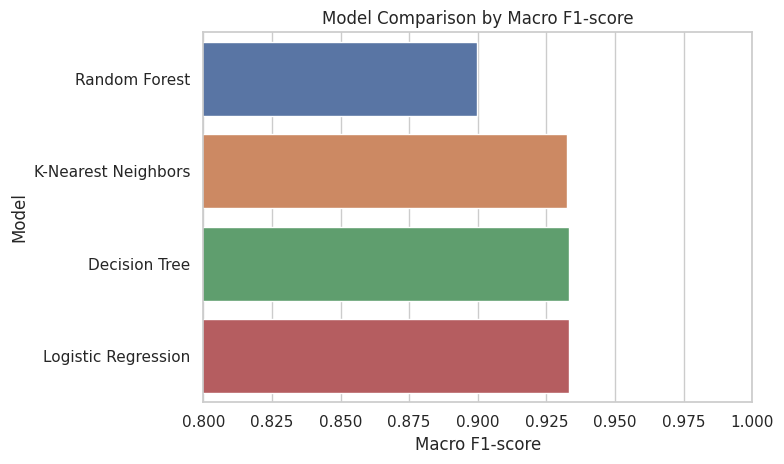

,Model,Accuracy,Precision (Macro),Recall (Macro),F1-score (Macro),CV F1 Mean,CV F1 Std
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333,0.957971,0.026772
1,Decision Tree,0.933333,0.933333,0.933333,0.933333,0.949605,0.017130
2,K-Nearest Neighbors,0.933333,0.944444,0.933333,0.932660,0.957971,0.026772
3,Random Forest,0.900000,0.902357,0.900000,0.899749,0.949406,0.031730


In [17]:
comparison_for_plot = model_comparison.sort_values("F1-score (Macro)", ascending=True)
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.barplot(data=comparison_for_plot, x="F1-score (Macro)", y="Model", hue="Model", legend=False, ax=ax)
ax.set_title("Model Comparison by Macro F1-score")
ax.set_xlabel("Macro F1-score")
ax.set_ylabel("Model")
ax.set_xlim(0.80, 1.00)
fig.tight_layout()
fig.savefig(IMAGES_DIR / "model_comparison_f1.png", dpi=180, bbox_inches="tight")
plt.show()

display(model_comparison)

## 23. Best Model Selection

The primary selection metric is **macro F1-score** on the held-out test set, followed by test accuracy and then mean cross-validation macro F1 as a tie-breaker. This keeps the decision evidence-based and transparent.

In [18]:
best_row = model_comparison.iloc[0]
best_model_name = best_row["Model"]

summary_text = f"""
### Best Model: {best_model_name}

- **Test Accuracy:** {best_row['Accuracy']:.4f}
- **Macro Precision:** {best_row['Precision (Macro)']:.4f}
- **Macro Recall:** {best_row['Recall (Macro)']:.4f}
- **Macro F1-score:** {best_row['F1-score (Macro)']:.4f}
- **5-fold CV Macro F1 Mean:** {best_row['CV F1 Mean']:.4f}

The model is selected using the ranking rule described above. If models have very similar test results, the cross-validation result provides additional evidence about stability across different training folds.
"""
display(Markdown(summary_text))

with open(OUTPUTS_DIR / "best_model_summary.txt", "w", encoding="utf-8") as f:
    f.write(f"Best Model: {best_model_name}\n")
    f.write(f"Accuracy: {best_row['Accuracy']:.4f}\n")
    f.write(f"Precision (Macro): {best_row['Precision (Macro)']:.4f}\n")
    f.write(f"Recall (Macro): {best_row['Recall (Macro)']:.4f}\n")
    f.write(f"F1-score (Macro): {best_row['F1-score (Macro)']:.4f}\n")
    f.write(f"CV F1 Mean: {best_row['CV F1 Mean']:.4f}\n")


### Best Model: Logistic Regression

- **Test Accuracy:** 0.9333
- **Macro Precision:** 0.9333
- **Macro Recall:** 0.9333
- **Macro F1-score:** 0.9333
- **5-fold CV Macro F1 Mean:** 0.9580

The model is selected using the ranking rule described above. If models have very similar test results, the cross-validation result provides additional evidence about stability across different training folds.


## 24. Key Insights

- Petal dimensions are the strongest discriminators between Iris species.
- Setosa is visually the most separable species.
- The main overlap occurs between Versicolor and Virginica.
- Scaling is applied only inside model pipelines where needed, preventing leakage from the test set.
- Multiple classical classifiers perform strongly on this small, clean, balanced dataset, so model selection should consider both held-out performance and stability rather than accuracy alone.

## 25. Final Conclusion

This project completed the full classification workflow: dataset inspection, quality checks, EDA, feature analysis, reproducible train/test splitting, model training, evaluation, confusion-matrix analysis, and evidence-based model selection. The saved outputs and visualizations provide a transparent record of the analysis and can be used in the project README, GitHub repository, and internship demo.